In [2]:
import os
import kagglehub

if os.path.exists("/content"):

    from google.colab import drive

    drive.mount("/content/drive")

    output_dir = "/content/drive/MyDrive/sample data"

    path = kagglehub.dataset_download(
        "apollo2506/eurosat-dataset",
        output_dir=output_dir
    )

    print("Running on Google Colab")
    print("Dataset path:", path)

else:

    path = kagglehub.dataset_download(
        "apollo2506/eurosat-dataset"
    )

    print("Running locally")
    print("Dataset path:", path)

Running locally
Dataset path: C:\Users\ani77\.cache\kagglehub\datasets\apollo2506\eurosat-dataset\versions\6


In [3]:
import os
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from PIL import Image
from torchvision import transforms
from sklearn.model_selection import train_test_split
torch.manual_seed(42)

In [4]:
import os

for root, dirs, files in os.walk(path):
    print(root)
    print("Folders:", dirs[:2])
    print("Files:", files[:2])
    print()
    break
  

C:\Users\ani77\.cache\kagglehub\datasets\apollo2506\eurosat-dataset\versions\6
Folders: ['EuroSAT', 'EuroSATallBands']
Files: []



In [5]:
def create_dataset(data_dir):
    images = []
    labels = []

    class_names = sorted(os.listdir(data_dir))
    for label, c_name in enumerate(class_names):
        class_dir = os.path.join(data_dir,c_name)

        if os.path.isdir(class_dir):
            print(class_dir)
            for image_name in os.listdir(class_dir):
                image_path = os.path.join(class_dir,image_name)

                images.append(image_path)
                labels.append(label)

    return images, labels

In [6]:
#data_dir= "/kaggle/input/eurosat-dataset/EuroSAT"
data_dir = os.path.join(path,"EuroSAT")
os.listdir(data_dir)



['AnnualCrop',
 'Forest',
 'HerbaceousVegetation',
 'Highway',
 'Industrial',
 'label_map.json',
 'Pasture',
 'PermanentCrop',
 'Residential',
 'River',
 'SeaLake',
 'test.csv',
 'train.csv',
 'validation.csv']

In [7]:
sorted(os.listdir(data_dir))

['AnnualCrop',
 'Forest',
 'HerbaceousVegetation',
 'Highway',
 'Industrial',
 'Pasture',
 'PermanentCrop',
 'Residential',
 'River',
 'SeaLake',
 'label_map.json',
 'test.csv',
 'train.csv',
 'validation.csv']

In [8]:
X, y = create_dataset(data_dir)

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

C:\Users\ani77\.cache\kagglehub\datasets\apollo2506\eurosat-dataset\versions\6\EuroSAT\AnnualCrop
C:\Users\ani77\.cache\kagglehub\datasets\apollo2506\eurosat-dataset\versions\6\EuroSAT\Forest
C:\Users\ani77\.cache\kagglehub\datasets\apollo2506\eurosat-dataset\versions\6\EuroSAT\HerbaceousVegetation
C:\Users\ani77\.cache\kagglehub\datasets\apollo2506\eurosat-dataset\versions\6\EuroSAT\Highway
C:\Users\ani77\.cache\kagglehub\datasets\apollo2506\eurosat-dataset\versions\6\EuroSAT\Industrial
C:\Users\ani77\.cache\kagglehub\datasets\apollo2506\eurosat-dataset\versions\6\EuroSAT\Pasture
C:\Users\ani77\.cache\kagglehub\datasets\apollo2506\eurosat-dataset\versions\6\EuroSAT\PermanentCrop
C:\Users\ani77\.cache\kagglehub\datasets\apollo2506\eurosat-dataset\versions\6\EuroSAT\Residential
C:\Users\ani77\.cache\kagglehub\datasets\apollo2506\eurosat-dataset\versions\6\EuroSAT\River
C:\Users\ani77\.cache\kagglehub\datasets\apollo2506\eurosat-dataset\versions\6\EuroSAT\SeaLake


In [9]:
len(X), len(y)

(27000, 27000)

In [10]:
X[:5]

['C:\\Users\\ani77\\.cache\\kagglehub\\datasets\\apollo2506\\eurosat-dataset\\versions\\6\\EuroSAT\\AnnualCrop\\AnnualCrop_1.jpg',
 'C:\\Users\\ani77\\.cache\\kagglehub\\datasets\\apollo2506\\eurosat-dataset\\versions\\6\\EuroSAT\\AnnualCrop\\AnnualCrop_10.jpg',
 'C:\\Users\\ani77\\.cache\\kagglehub\\datasets\\apollo2506\\eurosat-dataset\\versions\\6\\EuroSAT\\AnnualCrop\\AnnualCrop_100.jpg',
 'C:\\Users\\ani77\\.cache\\kagglehub\\datasets\\apollo2506\\eurosat-dataset\\versions\\6\\EuroSAT\\AnnualCrop\\AnnualCrop_1000.jpg',
 'C:\\Users\\ani77\\.cache\\kagglehub\\datasets\\apollo2506\\eurosat-dataset\\versions\\6\\EuroSAT\\AnnualCrop\\AnnualCrop_1001.jpg']

In [11]:
y[:5]

[0, 0, 0, 0, 0]

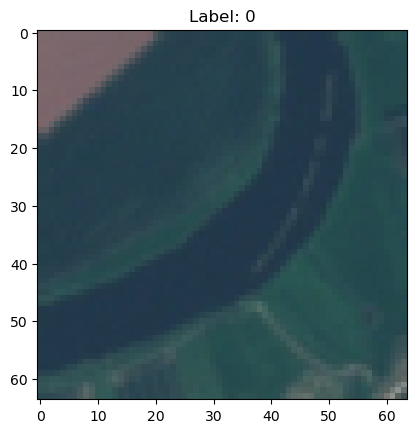

In [12]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(X_train[515]).convert("RGB")

plt.imshow(img)
plt.title(f"Label: {y_train[0]}")

plt.show()

In [13]:
class eurosat(Dataset):

    def __init__(self, images, labels, transforms = None):

        self.images = images
        self.labels = labels

        self.transforms = transforms

    def __len__(self):
        lenght = len(self.images)
        return lenght

    def __getitem__(self, index):
        image_path = self.images[index]
        image = Image.open(image_path).convert("RGB")

        labels = self.labels[index]

        if self.transforms:
            image = self.transforms

        return image, labels